In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.iolib.table import SimpleTable
from pandas.plotting import autocorrelation_plot

import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

**Содержание**
1. [Подготовка](#Подготовка)
2. [Анализ](#Анализ)
3. [ARIMA](#ARIMA)
4. [Обучение](#Обучение-с-помощью-Линейной-регрессии)
5. [Тестирование](#Тестирование)
6. [Вывод](#Вывод)

#  Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Постройте модель для такого предсказания.

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

Вам нужно:

1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.


Данные лежат в файле `taxi.csv`. Количество заказов находится в столбце `num_orders` (от англ. *number of orders*, «число заказов»).

## Подготовка

In [2]:
def load_dataset(name, **kwargs):
    """Читает датасет из локальной папки datasets/, при её отсутствии — с code.s3.yandex.net."""
    local = os.path.join('datasets', name)
    source = local if os.path.exists(local) else 'https://code.s3.yandex.net/datasets/' + name
    return pd.read_csv(source, **kwargs)

df = load_dataset('taxi.csv', index_col=[0], parse_dates=[0])
df.head()

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


In [4]:
df.describe()

,num_orders
count,26496.000000
mean,14.070463
std,9.211330
min,0.000000
25%,8.000000
50%,13.000000
75%,19.000000
max,119.000000


In [5]:
df = df.resample('1h').sum()
df

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43
...,...
2018-08-31 19:00:00,136
2018-08-31 20:00:00,154
2018-08-31 21:00:00,159


array([[<Axes: title={'center': 'num_orders'}>]], dtype=object)

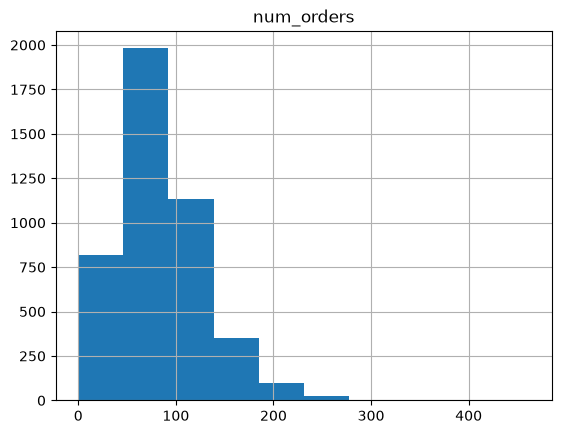

In [6]:
df.hist()

 Найдем коэффициент вариации: у нас относительно небольшой разброс целевого признака

In [7]:
print('V = %f' % (df['num_orders'].std() / df['num_orders'].mean()))

V = 0.533314


In [8]:
df.index.is_monotonic_increasing

True

## Анализ

In [9]:
row =  [u'JB', u'p-value', u'skew', u'kurtosis']
jb_test = sm.stats.stattools.jarque_bera(df['num_orders'])
SimpleTable(np.vstack([jb_test]), row)

JB,p-value,skew,kurtosis
3644.4335517264863,0.0,1.1885516779344458,6.762457138757449


Для проверки стационарности проведём обобщённый тест Дики-Фуллера на наличие единичных корней:

In [10]:
test = sm.tsa.adfuller(df['num_orders'])
print ('adf: ', test[0] )
print ('p-value: ', test[1])
print('Critical values: ', test[4])
if test[0]> test[4]['5%']: 
    print ('есть единичные корни, ряд не стационарен')
else:
    print ('единичных корней нет, ряд стационарен')

adf:  -3.0689242890279558
p-value:  0.028940051402612906
Critical values:  {'1%': np.float64(-3.431842162413052), '5%': np.float64(-2.8621993540813637), '10%': np.float64(-2.567120978470452)}
единичных корней нет, ряд стационарен


In [11]:
dif = df.diff(periods=1).dropna()
m = dif['num_orders'].index[len(dif['num_orders'].index)//2+1]
r1 = sm.stats.DescrStatsW(dif['num_orders'][m:])
r2 = sm.stats.DescrStatsW(dif['num_orders'][:m])
print ('p-value: ', sm.stats.CompareMeans(r1,r2).ttest_ind()[1])

p-value:  0.9587910561476498


<Axes: xlabel='datetime'>

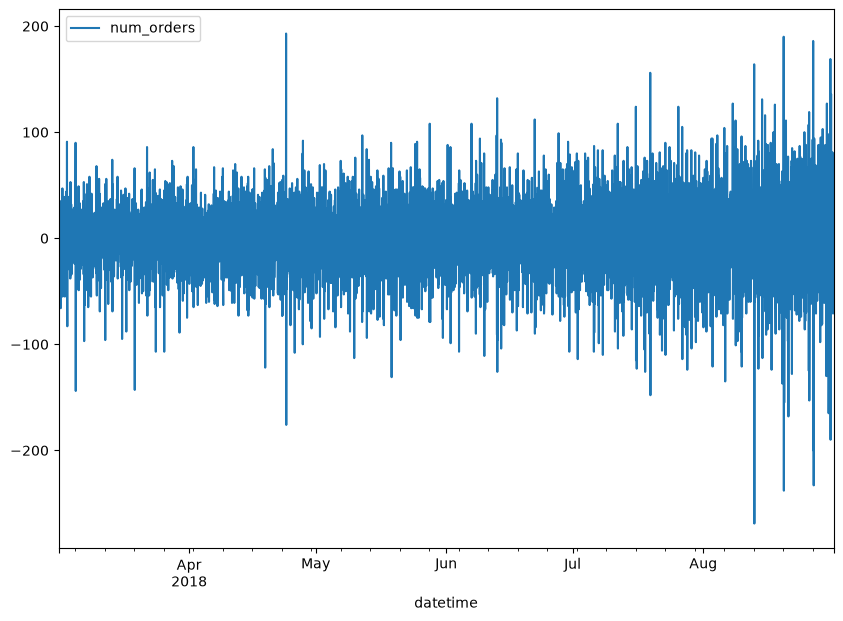

In [12]:
dif.plot(figsize=(10,7))

<Axes: xlabel='datetime'>

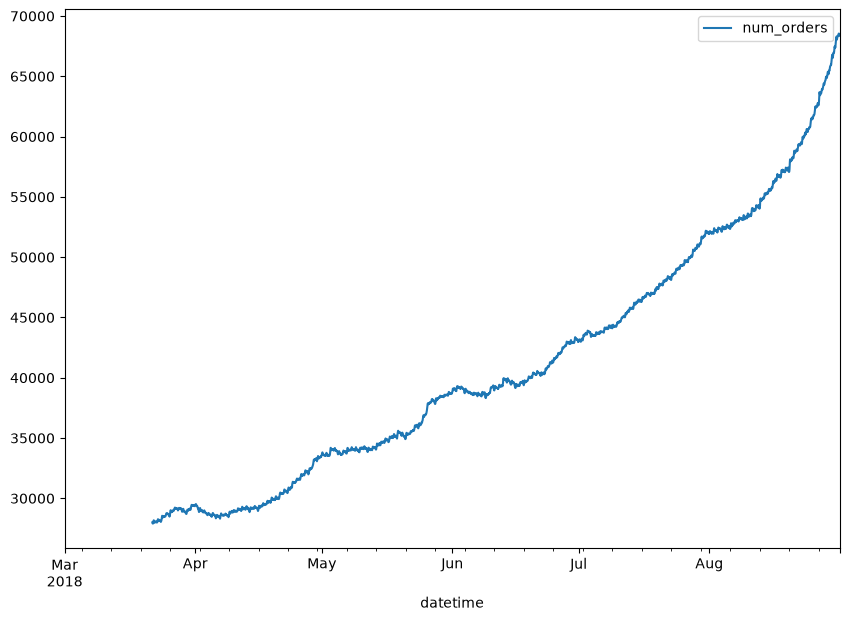

In [13]:
df.rolling(500).sum().plot(figsize = [10,7])

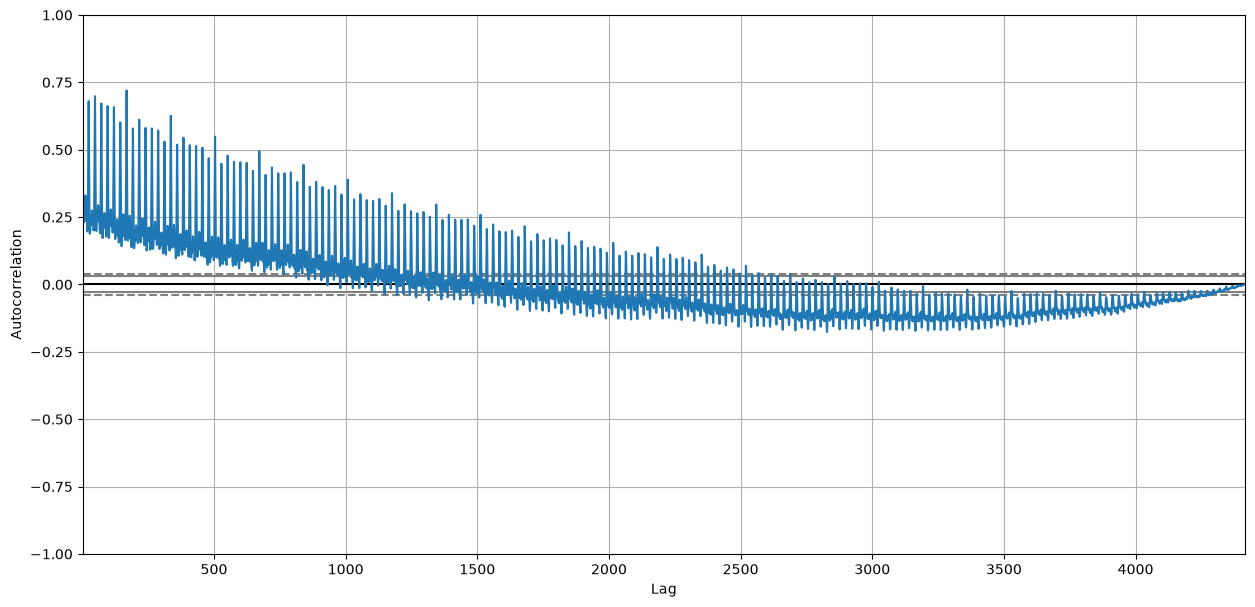

In [14]:
plt.figure(figsize=(15, 7))
autocorrelation_plot(df)
plt.show()

<Axes: xlabel='datetime'>

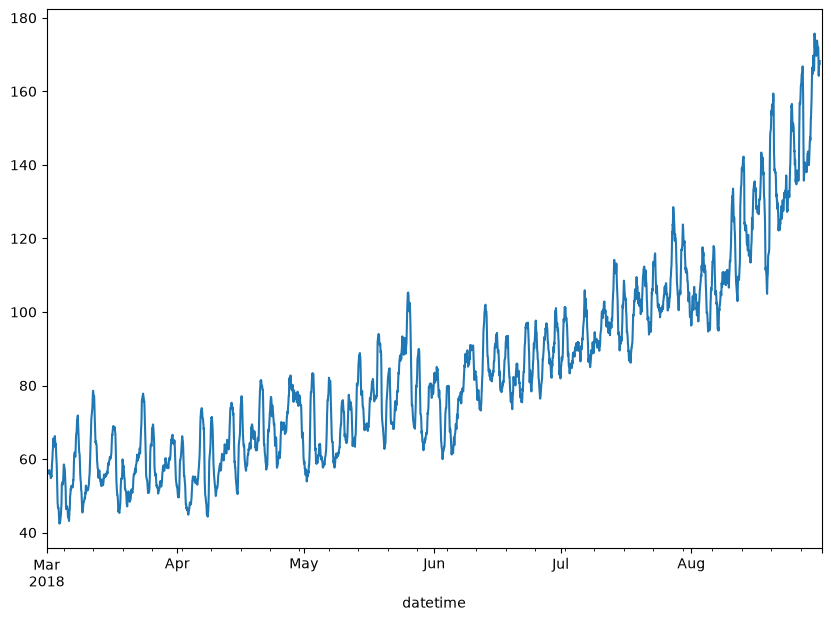

In [15]:
decomposed = seasonal_decompose(df)
decomposed.trend.plot(figsize = [10,7])

<Axes: xlabel='datetime'>

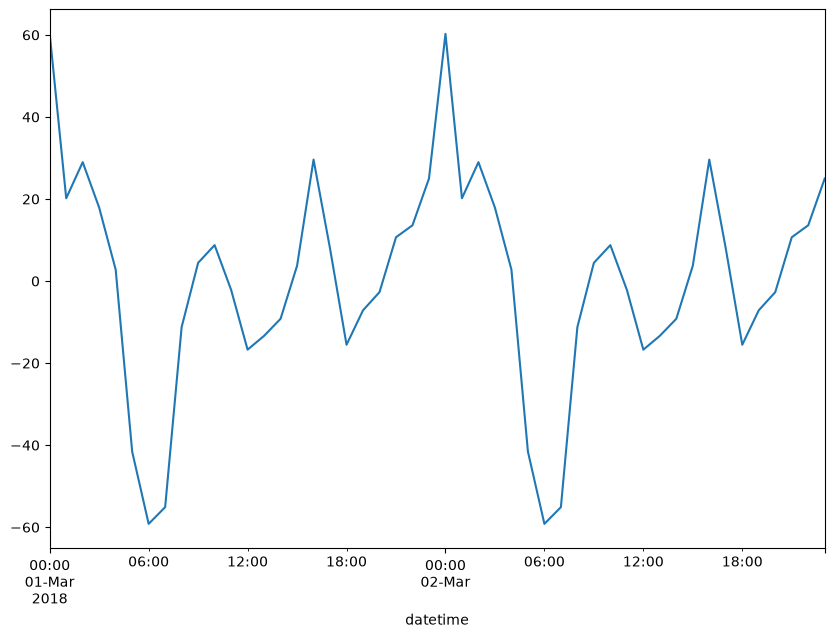

In [16]:
decomposed.seasonal['2018-03-01 00:00:00':'2018-03-02 23:00:00'].plot(figsize = [10,7])

<Axes: xlabel='datetime'>

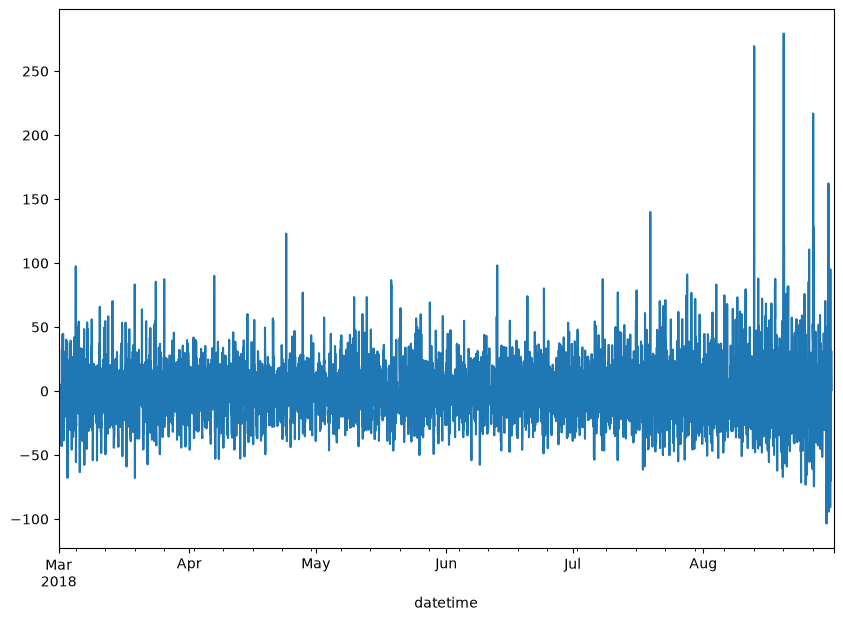

In [17]:
decomposed.resid.plot(figsize = [10,7])

<Axes: xlabel='datetime'>

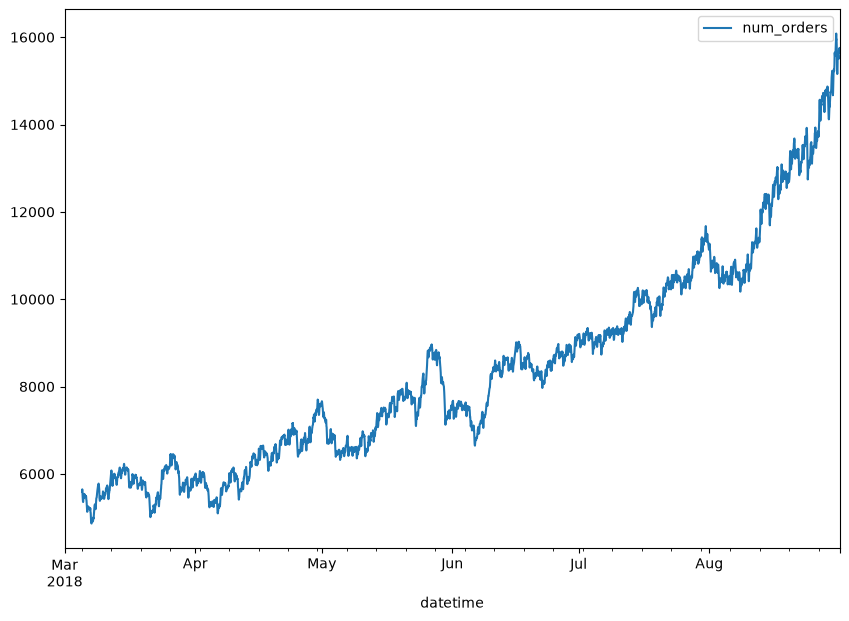

In [18]:
df.shift(fill_value=0).rolling(100).sum().plot(figsize = [10,7])

<Axes: xlabel='datetime'>

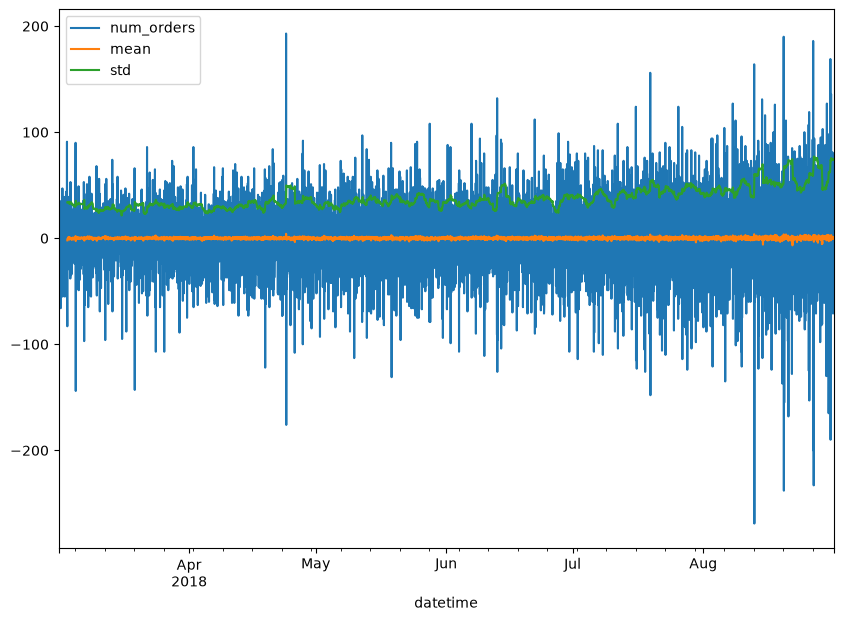

In [19]:

dif['mean'] = dif['num_orders'].rolling(50).mean()
dif['std'] = dif['num_orders'].rolling(50).std()
dif.plot(figsize = [10,7])

## ARIMA

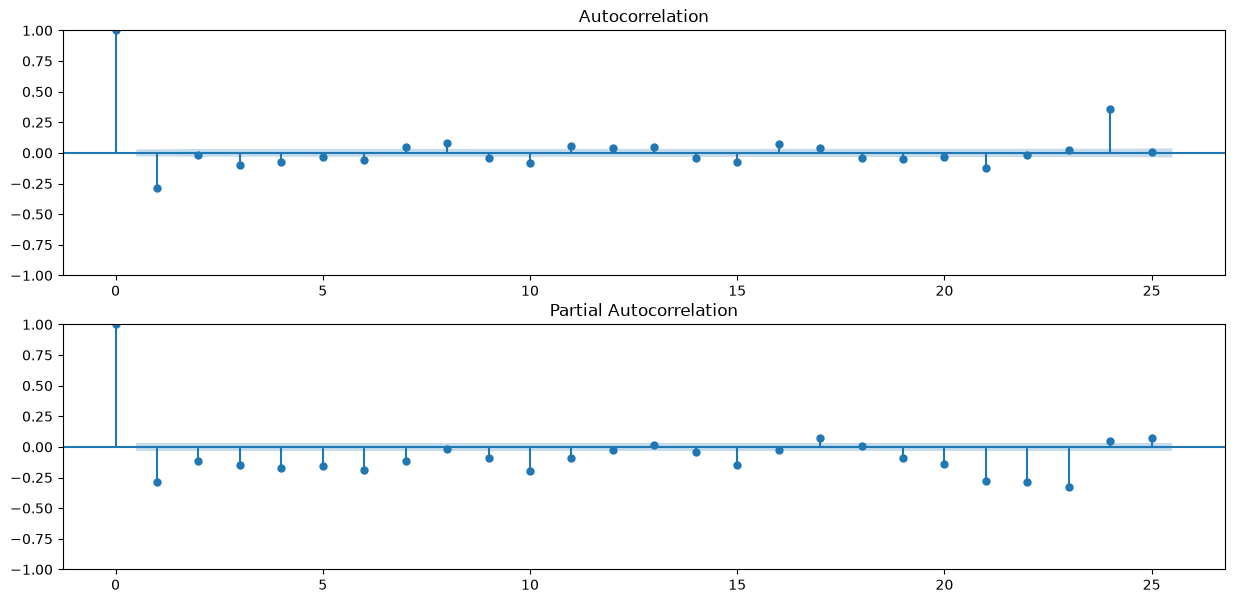

In [20]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7))
sm.graphics.tsa.plot_acf(dif['num_orders'].values.squeeze(), lags=25, ax=ax1)
sm.graphics.tsa.plot_pacf(dif['num_orders'], lags=25, ax=ax2)
plt.show()

In [21]:
train, test = train_test_split(df, shuffle=False, test_size=0.1)

print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())


2018-03-01 00:00:00 2018-08-13 13:00:00
2018-08-13 14:00:00 2018-08-31 23:00:00


In [22]:
# обучаем ARIMA только на обучающей выборке, прогнозируем тестовый период
model = sm.tsa.ARIMA(train['num_orders'].asfreq('h'), order=(1, 1, 1)).fit()

In [23]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             num_orders   No. Observations:                 3974
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -19262.940
Date:                Sat, 11 Jul 2026   AIC                          38531.879
Time:                        16:01:25   BIC                          38550.741
Sample:                    03-01-2018   HQIC                         38538.567
                         - 08-13-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4477      0.012     38.313      0.000       0.425       0.471
ma.L1         -0.9939      0.002   -540.723      0.000      -0.997      -0.990
sigma2       951.6468     15.453     61.583      0.000     921.359     981.934
===================================================================================
Ljung-Box (L1) (Q):                   1.19   Jarque-Bera (JB):              1125.40
Prob(Q):                              0.28   Prob(JB):                         0.00
Heteroskedasticity (H):               1.81   Skew:                             0.66
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.25
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [24]:
q_test = sm.tsa.stattools.acf(model.resid, qstat=True) #свойство resid, хранит остатки модели, qstat=True, означает что применяем указынный тест к коэф-ам
pd.DataFrame({'Q-stat':q_test[1], 'p-value':q_test[2]})

,Q-stat,p-value
0,1.331011,2.486254e-01
1,20.326078,3.856988e-05
2,25.124216,1.454411e-05
3,43.178410,9.502294e-09
4,52.689261,3.895466e-10
5,87.097146,1.213253e-16
6,87.780215,3.531635e-16
7,98.604211,8.231828e-18
8,126.516699,6.163454e-23
9,138.912905,7.038053e-25


In [25]:
pred = model.predict(test.index.min(), test.index.max())
trn = test['num_orders']
r2 = r2_score(trn, pred)
print('R^2: %1.2f' % r2)

R^2: -0.21


In [26]:
print('RMSE:', mean_squared_error(trn, pred) ** 0.5)

RMSE: 64.32847051857547


In [27]:
print('MAE:', mean_absolute_error(trn, pred))

MAE: 48.34190916058232


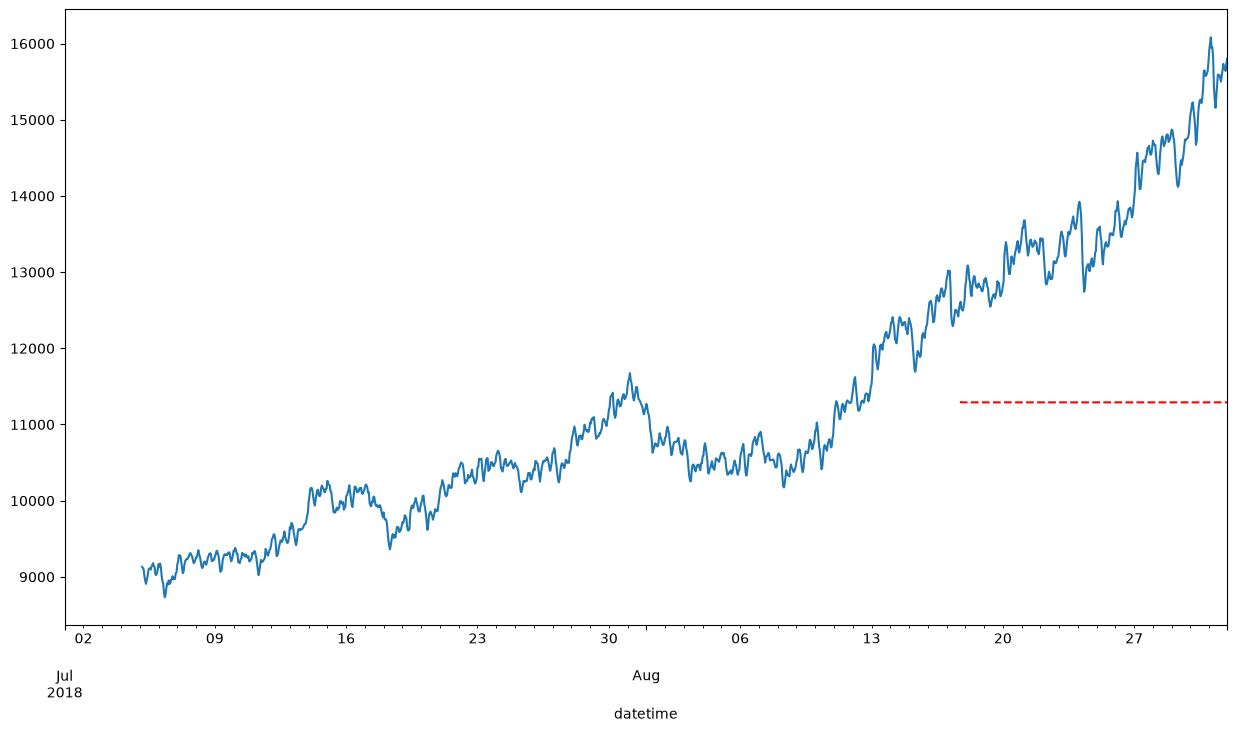

In [28]:
df['2018-07-01':]['num_orders'].rolling(100).sum().plot(figsize=(15, 8))
pred.rolling(100).sum().plot(style='r--')
plt.show()

ARIMA(1,1,1), обученная только на обучающей выборке, на длинном горизонте (весь тестовый период) даёт слабый прогноз (RMSE ≈ 64, R² < 0): статический многошаговый прогноз быстро вырождается к среднему уровню. Для почасового прогноза перейдём к ML-моделям с признаками времени и лагами.

## Обучение с помощью Линейной регрессии

Предсказание константной моделью

In [29]:
print("Среднее количество заказов такси:", test['num_orders'].mean())

pred_median = [train['num_orders'].median() for i in test['num_orders']]
print("RMSE:", mean_squared_error(test['num_orders'], pred_median)**0.5)

Среднее количество заказов такси: 139.55656108597285
RMSE: 87.15277582981295


Предсказание предыдущим значением

In [30]:
pred_previous = test['num_orders'].shift()
pred_previous.iloc[0] = train['num_orders'].iloc[-1]
print("RMSE:", mean_squared_error(test['num_orders'], pred_previous)**0.5)

RMSE: 58.856486242815066


In [31]:
def make_features(data, max_lag, rolling_mean_size):
    frame = data.copy()
    frame['hour'] = frame.index.hour
    frame['month'] = frame.index.month
    frame['day'] = frame.index.day
    frame['dayofweek'] = frame.index.dayofweek
   
    for lag in range(1, max_lag + 1):
        frame['lag_{}'.format(lag)] = frame['num_orders'].shift(lag)
    frame['rolling_mean'] = frame['num_orders'].shift().rolling(rolling_mean_size).mean()
    return(frame)

In [32]:
frame = make_features(df, 4, 4)
train, test = train_test_split(frame, shuffle=False, test_size=0.1)
train = train.dropna()

X_train = train.drop(['num_orders'], axis=1)
y_train = train['num_orders']
X_test = test.drop(['num_orders'], axis=1)
y_test = test['num_orders']
model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)
print("RMSE обучающей выборки:", mean_squared_error(y_train, model.predict(X_train))**0.5)
print("RMSE тестовой выборки: ", mean_squared_error(y_test, pred)**0.5)

RMSE обучающей выборки: 30.500374252442192
RMSE тестовой выборки:  52.57450685373694


## Тестирование

In [33]:
train.shape, test.shape

((3970, 10), (442, 10))

In [34]:
print(frame.shape[0]//10+1)

442


In [35]:
ts_cv = TimeSeriesSplit(
    n_splits=5,
    test_size=frame.shape[0]//10+1
)

In [36]:
train.shape, test.shape

((3970, 10), (442, 10))

In [37]:
def score_(model, X_train, X_test, y_train, y_test, stopping_rounds, metric):
    # для ранней остановки выделяем хвост обучающей выборки, чтобы не подсматривать в тест
    val_size = len(X_train) // 10
    X_tr, X_val = X_train.iloc[:-val_size], X_train.iloc[-val_size:]
    y_tr, y_val = y_train.iloc[:-val_size], y_train.iloc[-val_size:]
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric=metric,
              callbacks=[lgb.early_stopping(stopping_rounds, verbose=False)])
    preds = model.predict(X_test)
    return mean_squared_error(y_test, preds) ** 0.5

In [38]:
%%time
model = LGBMRegressor(n_estimators=1000, random_state=12345, verbose=-1, n_jobs=4)
score_(model, X_train, X_test, y_train, y_test, 100, 'rmse')

CPU times: user 561 ms, sys: 11.5 ms, total: 573 ms
Wall time: 146 ms


54.14437812418253

In [39]:
def evaluate(model, params):
    grid = GridSearchCV(model, param_grid=params, scoring='neg_mean_squared_error', cv=ts_cv)
    grid.fit(X_train, y_train)
    pred = grid.predict(X_test)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    print('RMSE', rmse)
    print(grid.best_params_)

In [40]:
%%time
model = LGBMRegressor(n_estimators=100, random_state=12345, verbose=-1, n_jobs=4)
evaluate(model, {'learning_rate':np.arange(0.1, 1, 0.2)})

RMSE 45.04210854822016
{'learning_rate': np.float64(0.1)}
CPU times: user 7.71 s, sys: 176 ms, total: 7.89 s
Wall time: 1.98 s


In [41]:
%%time
model = LGBMRegressor(n_estimators=100, random_state=12345, verbose=-1, learning_rate=0.1, n_jobs=4)
evaluate(model, {'reg_lambda':np.arange(0, 20, 2)})

RMSE 45.06721877278898
{'reg_lambda': np.int64(2)}
CPU times: user 12.4 s, sys: 340 ms, total: 12.7 s
Wall time: 3.19 s


In [42]:
%%time
model = LGBMRegressor(random_state=12345, verbose=-1, learning_rate=0.3, n_jobs=4, reg_lambda=2, n_estimators=100)
evaluate(model, {'reg_alpha':np.arange(0, 20, 2)})

RMSE 45.663327377973225
{'reg_alpha': np.int64(6)}
CPU times: user 8.11 s, sys: 112 ms, total: 8.22 s
Wall time: 2.06 s


In [43]:
%%time
model = LGBMRegressor(random_state=12345, verbose=-1, learning_rate=0.3, n_jobs=4, reg_lambda=2, reg_alpha =10)
evaluate(model, {'n_estimators':[100,300]})

RMSE 44.605469503184395
{'n_estimators': 100}
CPU times: user 3.32 s, sys: 39.8 ms, total: 3.36 s
Wall time: 939 ms


## Вывод
Данные ресемплированы по одному часу и проанализированы (тренд, суточная сезонность, стационарность). Обучены и сравнены модели: константный baseline (RMSE 87.2), предсказание предыдущим значением (58.9), ARIMA (64.3 на длинном горизонте), линейная регрессия с лагами (52.6) и LightGBM с признаками времени и лагами.

Лучший результат — **LightGBM: RMSE = 44.6** на тестовой выборке, что ниже требуемого порога 48. Гиперпараметры подобраны кросс-валидацией по времени (`TimeSeriesSplit`).